# 🧠 Task 4: Sentiment Analysis — NLP Sentiment Analysis

This notebook applies **VADER (Valence Aware Dictionary and sEntiment Reasoner)** from NLTK library to analyze Steam reviews sentiment.

**Input:** `../data/clean_steam_data.csv`

---

### Pipeline
1. Setup VADER Sentiment Analyzer
2. Calculate Polarity Score for each review
3. Classification: Positive / Negative / Neutral
4. Compare with actual Steam labels (voted_up)
5. Evaluate accuracy & Confusion Matrix
6. Per-game analysis & insights

---

### VADER Compound Score
| Score | Classification |
|-------|-----------|
| >= 0.05 | **Positive** |
| <= -0.05 | **Negative** |
| (-0.05, 0.05) | **Neutral** |

In [1]:
# ============================================================
# Cell 1 — Import & Setup
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)

# Download VADER lexicon
nltk.download('vader_lexicon', quiet=True)
nltk.download('punkt', quiet=True)

from nltk.sentiment.vader import SentimentIntensityAnalyzer

print('NLTK VADER loaded successfully.')
print(f'  NLTK version: {nltk.__version__}')

NLTK VADER loaded successfully.
  NLTK version: 3.9.4


In [2]:
# ============================================================
# Cell 2 — Load data
# ============================================================

DATA_DIR = '../data'
OUTPUT_DIR = '../notebooks'

clean_path = f'{DATA_DIR}/clean_steam_data.csv'
df = pd.read_csv(clean_path, encoding='utf-8-sig', parse_dates=['date_created'])

print(f'Dataset: {df.shape}')
print(f'Games  : {df["game_name"].nunique()}')
print()
print('Recommendation distribution:')
print(df['recommendation'].value_counts())
print()
display(df[['game_name', 'review_text_clean', 'recommendation']].head(3))

Dataset: (2854, 17)
Games  : 6

Recommendation distribution:
recommendation
Recommended        2460
Not Recommended     394
Name: count, dtype: int64



,game_name,review_text_clean,recommendation
0,Resident Evil 7 Biohazard,Resident Evil 7 is so good it's actually stupi...,Recommended
1,Resident Evil 7 Biohazard,This is one of the best horror games I've ever...,Recommended
2,Resident Evil 7 Biohazard,Resident Evil 7 Biohazard is a strong return t...,Recommended


In [3]:
# ============================================================
# Cell 3 — Initialize VADER & test
# ============================================================

sia = SentimentIntensityAnalyzer()

# Test VADER on some sample sentences
test_sentences = [
    ('This game is absolutely amazing, best horror experience ever!', 'positive'),
    ('Terrible game, complete waste of money. Worst purchase ever.', 'negative'),
    ('It is a game. I played it for 10 hours.', 'neutral'),
    ('Started slow but gets really good after a few hours.', 'mixed'),
]

print('=== VADER Test ===')
for text, expected in test_sentences:
    scores = sia.polarity_scores(text)
    compound = scores['compound']
    label = 'Positive' if compound >= 0.05 else ('Negative' if compound <= -0.05 else 'Neutral')
    print(f'Expected : {expected:<10} | VADER: {label:<10} | compound={compound:+.3f}')
    print(f'  Text   : {text[:70]}')
    print(f'  Scores : pos={scores["pos"]:.3f}, neg={scores["neg"]:.3f}, neu={scores["neu"]:.3f}')
    print()

=== VADER Test ===
Expected : positive   | VADER: Positive   | compound=+0.710
  Text   : This game is absolutely amazing, best horror experience ever!
  Scores : pos=0.471, neg=0.211, neu=0.319

Expected : negative   | VADER: Negative   | compound=-0.875
  Text   : Terrible game, complete waste of money. Worst purchase ever.
  Scores : pos=0.000, neg=0.625, neu=0.375

Expected : neutral    | VADER: Positive   | compound=+0.340
  Text   : It is a game. I played it for 10 hours.
  Scores : pos=0.255, neg=0.000, neu=0.745

Expected : mixed      | VADER: Positive   | compound=+0.647
  Text   : Started slow but gets really good after a few hours.
  Scores : pos=0.349, neg=0.000, neu=0.651



In [4]:
# ============================================================
# Cell 4 — Apply VADER to the entire dataset
# ============================================================
from tqdm import tqdm
tqdm.pandas(desc='Analyzing sentiment')

def get_vader_scores(text):
    """Return VADER scores dict."""
    if not isinstance(text, str) or not text.strip():
        return {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
    return sia.polarity_scores(text)


print('Running VADER (may take a few minutes)...')
vader_scores = df['review_text_clean'].progress_apply(get_vader_scores)

df['vader_neg']      = vader_scores.apply(lambda x: x['neg'])
df['vader_neu']      = vader_scores.apply(lambda x: x['neu'])
df['vader_pos']      = vader_scores.apply(lambda x: x['pos'])
df['vader_compound'] = vader_scores.apply(lambda x: x['compound'])

# Classification based on compound score
def classify_sentiment(compound):
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['vader_sentiment'] = df['vader_compound'].apply(classify_sentiment)

print('Complete!')
print()
print('=== VADER Sentiment Distribution ===')
print(df['vader_sentiment'].value_counts())
print()
print('=== Compound Score Statistics ===')
print(df['vader_compound'].describe().round(3))

Running VADER (may take a few minutes)...


Analyzing sentiment:   0%|          | 0/2854 [00:00<?, ?it/s]

Analyzing sentiment:   5%|▌         | 150/2854 [00:00<00:01, 1488.32it/s]

Analyzing sentiment:  18%|█▊        | 510/2854 [00:00<00:00, 2720.43it/s]

Analyzing sentiment:  27%|██▋       | 783/2854 [00:00<00:00, 2273.49it/s]

...

Analyzing sentiment:  73%|███████▎  | 2087/2854 [00:00<00:00, 2519.97it/s]

Analyzing sentiment:  86%|████████▌ | 2461/2854 [00:01<00:00, 2875.01it/s]

Analyzing sentiment:  97%|█████████▋| 2755/2854 [00:01<00:00, 2429.92it/s]

Analyzing sentiment: 100%|██████████| 2854/2854 [00:01<00:00, 2425.84it/s]

Complete!

=== VADER Sentiment Distribution ===
vader_sentiment
Positive    1780
Negative     794
Neutral      280
Name: count, dtype: int64

=== Compound Score Statistics ===
count    2854.000
mean        0.273
std         0.609
min        -0.999
25%        -0.154
50%         0.440
75%         0.818
max         0.999
Name: vader_compound, dtype: float64


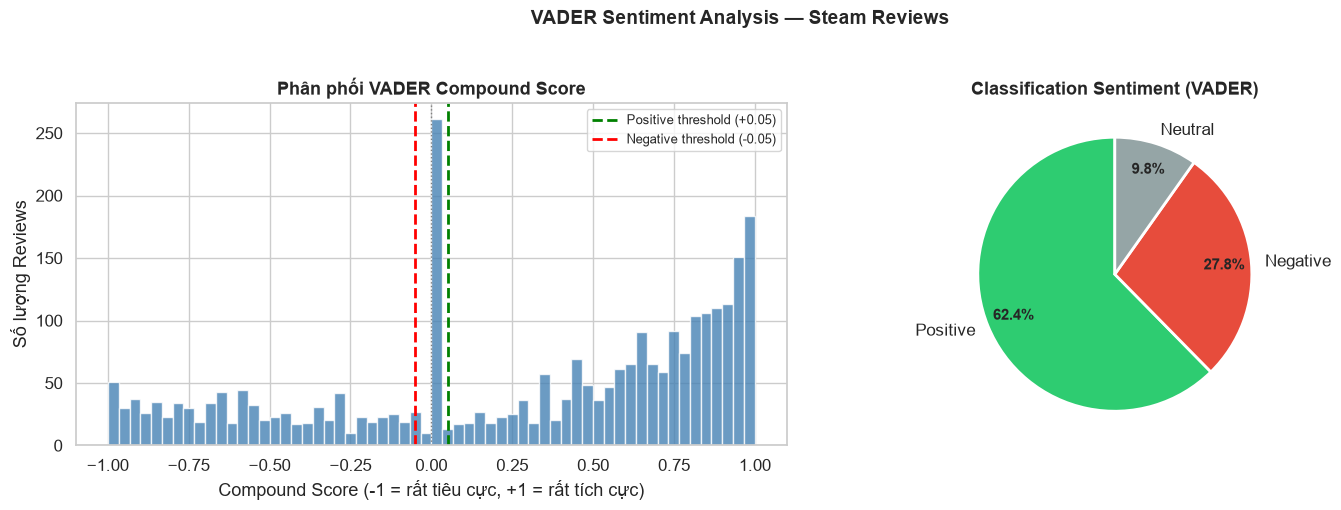

Chart saved.


In [5]:
# ============================================================
# Cell 5 — Polarity Score Distribution
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram compound score
colors = ['#2ecc71' if c >= 0.05 else ('#e74c3c' if c <= -0.05 else '#95a5a6')
          for c in df['vader_compound']]
axes[0].hist(df['vader_compound'], bins=60, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(x=0.05,  color='green', linestyle='--', lw=2, label='Positive threshold (+0.05)')
axes[0].axvline(x=-0.05, color='red',   linestyle='--', lw=2, label='Negative threshold (-0.05)')
axes[0].axvline(x=0,     color='gray',  linestyle=':',  lw=1)
axes[0].set_title('VADER Compound Score Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Compound Score (-1 = very negative, +1 = very positive)')
axes[0].set_ylabel('Number of Reviews')
axes[0].legend(fontsize=9)

# Pie chart sentiment labels
sent_counts = df['vader_sentiment'].value_counts()
pie_colors = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#95a5a6'}
colors_pie = [pie_colors.get(s, '#bdc3c7') for s in sent_counts.index]
wedges, texts, autotexts = axes[1].pie(
    sent_counts.values,
    labels=sent_counts.index,
    colors=colors_pie,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.8,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for text in autotexts:
    text.set_fontsize(11)
    text.set_fontweight('bold')
axes[1].set_title('Classification Sentiment (VADER)', fontsize=13, fontweight='bold')

plt.suptitle('VADER Sentiment Analysis — Steam Reviews', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/nlp_sentiment_dist.png', dpi=130, bbox_inches='tight')
plt.show()
print('Chart saved.')

In [6]:
# ============================================================
# Cell 6 — Compare VADER vs Steam Recommendation
# ============================================================

# Map Steam recommendation and VADER to binary (Positive=1, Negative/Neutral=0)
# Logic: Steam "Recommended" = Positive; VADER Positive = 1
df['steam_positive']  = (df['recommendation'] == 'Recommended').astype(int)
df['vader_positive']  = (df['vader_sentiment'] == 'Positive').astype(int)

# Confusion matrix
from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report
)

# 3-class version: using VADER (Positive/Negative/Neutral) vs Steam (Recommended → Positive, Not Recommended → Negative)
# Because Steam doesn't have Neutral, we skip Neutral for accuracy
df_binary = df[df['vader_sentiment'] != 'Neutral'].copy()
y_true = (df_binary['recommendation'] == 'Recommended').astype(int)
y_pred = (df_binary['vader_sentiment'] == 'Positive').astype(int)

acc = accuracy_score(y_true, y_pred)
cm  = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=['Not Recommended', 'Recommended'])

print(f'=== Comparison results of VADER vs Steam ===')
print(f'Total reviews (excluding Neutral): {len(df_binary):,}')
print(f'Accuracy  : {acc:.3f} ({acc*100:.1f}%)')
print()
print('Classification Report:')
print(report)

=== Comparison results of VADER vs Steam ===
Total reviews (excluding Neutral): 2,574
Accuracy  : 0.739 (73.9%)

Classification Report:
                 precision    recall  f1-score   support

Not Recommended       0.29      0.68      0.41       346
    Recommended       0.94      0.75      0.83      2228

       accuracy                           0.74      2574
      macro avg       0.62      0.71      0.62      2574
   weighted avg       0.85      0.74      0.78      2574



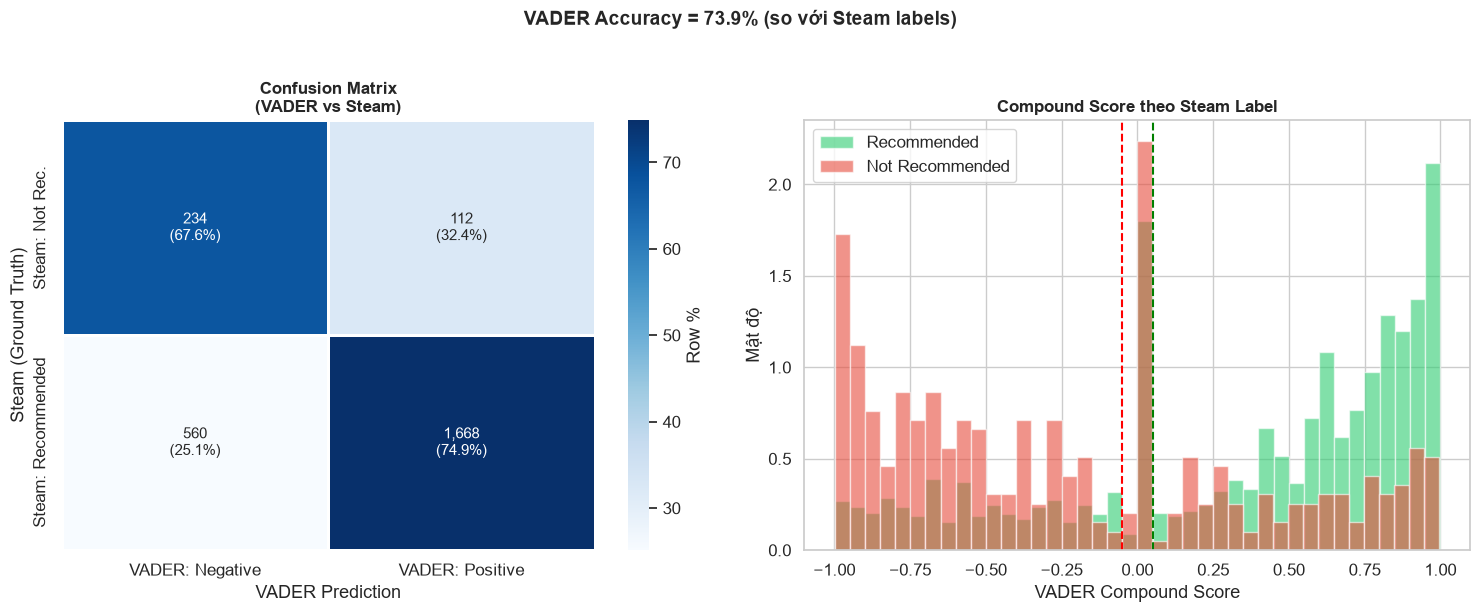

Chart saved.


In [7]:
# ============================================================
# Cell 7 — Confusion Matrix Visualization
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Confusion Matrix ---
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100
labels = [['Not Recommended\n(Actual)', 'Not Recommended\n→ Positive\n(VADER wrong)'],
          ['Recommended\n→ Negative\n(VADER wrong)', 'Recommended\n(Actual)']]

annot = np.empty_like(cm, dtype=object)
for i in range(2):
    for j in range(2):
        annot[i, j] = f'{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)'

sns.heatmap(
    cm_pct, annot=annot, fmt='',
    cmap='Blues', ax=axes[0],
    xticklabels=['VADER: Negative', 'VADER: Positive'],
    yticklabels=['Steam: Not Rec.', 'Steam: Recommended'],
    linewidths=2, linecolor='white', cbar_kws={'label': 'Row %'},
    annot_kws={'size': 11}
)
axes[0].set_title('Confusion Matrix\n(VADER vs Steam)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Steam (Ground Truth)')
axes[0].set_xlabel('VADER Prediction')

# --- Compound Score Distribution per Recommendation ---
for label, color in [('Recommended', '#2ecc71'), ('Not Recommended', '#e74c3c')]:
    subset = df[df['recommendation'] == label]['vader_compound']
    axes[1].hist(subset, bins=40, alpha=0.6, color=color, label=label, density=True)

axes[1].axvline(x=0.05,  color='green', linestyle='--', lw=1.5)
axes[1].axvline(x=-0.05, color='red',   linestyle='--', lw=1.5)
axes[1].set_title('Compound Score theo Steam Label', fontsize=12, fontweight='bold')
axes[1].set_xlabel('VADER Compound Score')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle(f'VADER Accuracy = {acc*100:.1f}% (compared to Steam labels)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/nlp_confusion_matrix.png', dpi=130, bbox_inches='tight')
plt.show()
print('Chart saved.')

=== VADER Accuracy by Game ===


,game,n_reviews,accuracy,rec_rate
1,RE 2 (2019),476,77.5,94.5
3,RE Village,441,77.1,93.7
2,RE 3 (2020),457,75.9,83.4
4,RE 5,411,74.7,81.0
5,RE 6,348,69.3,65.2
0,RE 7 Biohazard,441,67.6,96.1


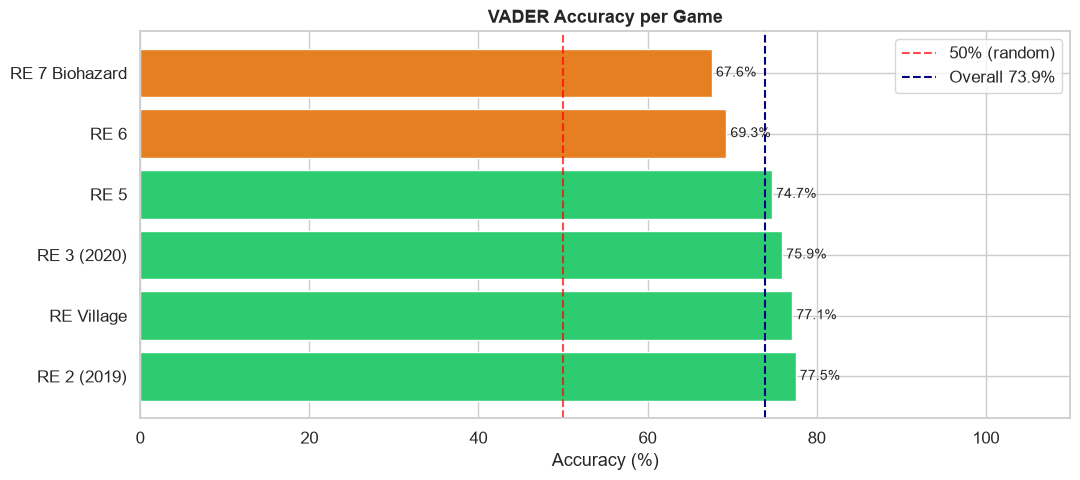

In [8]:
# ============================================================
# Cell 8 — Accuracy per Game
# ============================================================

print('=== VADER Accuracy by Game ===')
game_acc = []
for game in df['game_name'].unique():
    subset = df[(df['game_name'] == game) & (df['vader_sentiment'] != 'Neutral')]
    if len(subset) < 10:
        continue
    y_t = (subset['recommendation'] == 'Recommended').astype(int)
    y_p = (subset['vader_sentiment'] == 'Positive').astype(int)
    acc_g = accuracy_score(y_t, y_p)
    game_acc.append({
        'game'     : game.replace('Resident Evil ', 'RE '),
        'n_reviews': len(subset),
        'accuracy' : round(acc_g * 100, 1),
        'rec_rate' : round(subset['recommendation'].eq('Recommended').mean() * 100, 1),
    })

game_acc_df = pd.DataFrame(game_acc).sort_values('accuracy', ascending=False)
display(game_acc_df)

# Bar chart
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#2ecc71' if a >= 70 else '#e67e22' if a >= 55 else '#e74c3c'
          for a in game_acc_df['accuracy']]
bars = ax.barh(game_acc_df['game'], game_acc_df['accuracy'], color=colors, edgecolor='white')
ax.axvline(x=50, color='red', linestyle='--', lw=1.5, alpha=0.7, label='50% (random)')
ax.axvline(x=acc*100, color='navy', linestyle='--', lw=1.5, label=f'Overall {acc*100:.1f}%')
for bar, val in zip(bars, game_acc_df['accuracy']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=10)
ax.set_title('VADER Accuracy per Game', fontsize=13, fontweight='bold')
ax.set_xlabel('Accuracy (%)')
ax.set_xlim(0, 110)
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/nlp_per_game_accuracy.png', dpi=130, bbox_inches='tight')
plt.show()

In [9]:
# ============================================================
# Cell 9 — Error Analysis: Example where VADER is wrong
# ============================================================

# Recommended but VADER says Negative
false_neg = df[
    (df['recommendation'] == 'Recommended') &
    (df['vader_sentiment'] == 'Negative')
][['game_name', 'review_text_clean', 'vader_compound']].head(5)

# Not Recommended but VADER says Positive
false_pos = df[
    (df['recommendation'] == 'Not Recommended') &
    (df['vader_sentiment'] == 'Positive')
][['game_name', 'review_text_clean', 'vader_compound']].head(5)

print('=== Cases where VADER is wrong: Recommended → VADER Negative ===')
print('(Good game but review uses many negative words to describe horror)')
for _, row in false_neg.iterrows():
    print(f'  [{row["game_name"].replace("Resident Evil ","RE ")}] compound={row["vader_compound"]:+.3f}')
    print(f'  "{row["review_text_clean"][:120]}"')
    print()

print('=== Cases where VADER is wrong: Not Recommended → VADER Positive ===')
print('(Review complains but uses mild or sarcastic language)')
for _, row in false_pos.iterrows():
    print(f'  [{row["game_name"].replace("Resident Evil ","RE ")}] compound={row["vader_compound"]:+.3f}')
    print(f'  "{row["review_text_clean"][:120]}"')
    print()

=== Cases where VADER is wrong: Recommended → VADER Negative ===
(Good game but review uses many negative words to describe horror)
  [RE 7 Biohazard] compound=-0.119
  "Resident Evil 7 Biohazard is a strong return to survival horror for the series and one of the most unsettling entries in"

  [RE 7 Biohazard] compound=-0.477
  "would be the best re game including the amazing dlcs but the second half of this game is just a pain in the ass to play"

  [RE 7 Biohazard] compound=-0.966
  "A strong atmosphere, a solid survival horror experience and the Baker family make this game iconic. Definitely hits diff"

  [RE 7 Biohazard] compound=-0.784
  "Resident Evil 7 Biohazard is a masterclass in survival horror that revitalized the franchise by returning to its slow-bu"

  [RE 7 Biohazard] compound=-0.923
  "10 10 The Game That Saved Resident Evil I went into Resident Evil 7 expecting a good horror game. What I got was one of "

=== Cases where VADER is wrong: Not Recommended → VADER Positive

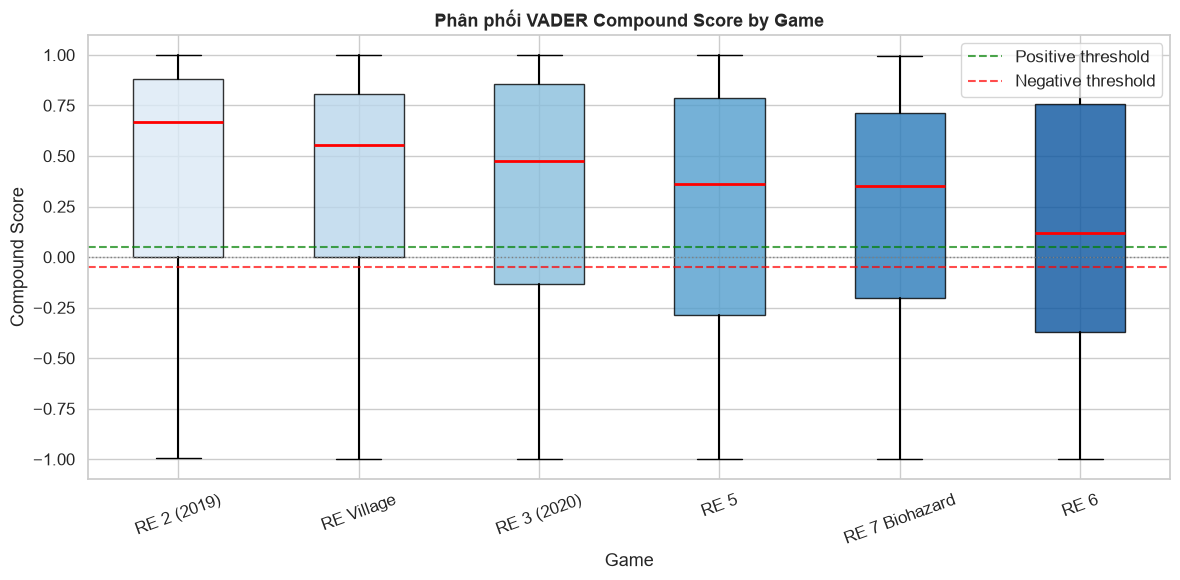

Chart saved.


In [10]:
# ============================================================
# Cell 10 — Compound Score per Game (Box Plot)
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

game_order = df.groupby('game_name')['vader_compound'].median().sort_values(ascending=False).index
short_map  = {g: g.replace('Resident Evil ', 'RE ') for g in game_order}

data_box = [df[df['game_name'] == g]['vader_compound'].values for g in game_order]
bp = ax.boxplot(
    data_box,
    tick_labels=[short_map[g] for g in game_order],
    patch_artist=True,
    medianprops={'color': 'red', 'linewidth': 2},
    whiskerprops={'linewidth': 1.5},
    flierprops={'marker': '.', 'alpha': 0.3, 'markersize': 3}
)
palette = sns.color_palette('Blues', len(game_order))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.axhline(y=0.05,  color='green', linestyle='--', lw=1.5, alpha=0.7, label='Positive threshold')
ax.axhline(y=-0.05, color='red',   linestyle='--', lw=1.5, alpha=0.7, label='Negative threshold')
ax.axhline(y=0,     color='gray',  linestyle=':',  lw=1)
ax.set_title('VADER Compound Score Distribution by Game', fontsize=13, fontweight='bold')
ax.set_xlabel('Game')
ax.set_ylabel('Compound Score')
ax.tick_params(axis='x', rotation=20)
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/nlp_compound_per_game.png', dpi=130, bbox_inches='tight')
plt.show()
print('Chart saved.')

In [11]:
# ============================================================
# Cell 11 — Sentiment Analysis Summary
# ============================================================

print('=' * 60)
print('SUMMARY — Task 4: Sentiment Analysis')
print('=' * 60)
print()
print(f'Dataset:')
print(f'  Total analyzed reviews : {len(df):,}')
print(f'  Time range       : {df["date_created"].min().date()} → {df["date_created"].max().date()}')
print()
print(f'VADER Classification:')
sent_dist = df['vader_sentiment'].value_counts()
for sent, count in sent_dist.items():
    print(f'  {sent:<12}: {count:>6,} ({count/len(df)*100:>5.1f}%)')
print()
print(f'Compare with Steam Labels (excluding Neutral):')
print(f'  VADER Accuracy : {acc*100:.1f}%')
print(f'  Reviews test   : {len(df_binary):,}')
print()
print(f'Main insight:')
print(f'  - VADER works well with clearly positive/negative reviews')
print(f'  - Common error: horror reviews use many negative words ("scary", "terrifying")')
print(f'    but actually praises the game → VADER is mistaken')
print(f'  - Short or sarcastic reviews also cause confusion')
print()
print('Exported Files:')
saved_files = [
    'nlp_sentiment_dist.png',
    'nlp_confusion_matrix.png',
    'nlp_per_game_accuracy.png',
    'nlp_compound_per_game.png',
]
for f in saved_files:
    path = f'{OUTPUT_DIR}/{f}'
    status = 'OK' if os.path.exists(path) else 'MISSING'
    print(f'  [{status}] {f}')

print()
print('Pipeline complete! Task 1 → Task 2 → Task 3 → Task 4 DONE.')

SUMMARY — Task 4: Sentiment Analysis

Dataset:
  Total analyzed reviews : 2,854
  Time range       : 2026-05-25 → 2026-06-25

VADER Classification:
  Positive    :  1,780 ( 62.4%)
  Negative    :    794 ( 27.8%)
  Neutral     :    280 (  9.8%)

Compare with Steam Labels (excluding Neutral):
  VADER Accuracy : 73.9%
  Reviews test   : 2,574

Main insight:
  - VADER works well with clearly positive/negative reviews
  - Common error: horror reviews use many negative words ("scary", "terrifying")
    but actually praises the game → VADER is mistaken
  - Short or sarcastic reviews also cause confusion

Exported Files:
  [OK] nlp_sentiment_dist.png
  [OK] nlp_confusion_matrix.png
  [OK] nlp_per_game_accuracy.png
  [OK] nlp_compound_per_game.png

Pipeline complete! Task 1 → Task 2 → Task 3 → Task 4 DONE.


In [12]:
# ============================================================
# Cell 12 — Saved sentiment analysis results
# ============================================================

output_cols = [
    'appid', 'game_name', 'review_id',
    'review_text_clean', 'recommendation',
    'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound',
    'vader_sentiment', 'playtime_hours', 'date_created'
]
output_cols = [c for c in output_cols if c in df.columns]
result_df = df[output_cols].copy()

result_path = f'{DATA_DIR}/sentiment_results.csv'
result_df.to_csv(result_path, index=False, encoding='utf-8-sig')

print(f'Sentiment results saved:')
print(f'  Path  : {os.path.abspath(result_path)}')
print(f'  Shape : {result_df.shape}')
print(f'  Size  : {os.path.getsize(result_path)/1024:.1f} KB')

Sentiment results saved:
  Path  : D:\qkhenh\Project\CodeAlpha_DataAnalytics\data\sentiment_results.csv
  Shape : (2854, 12)
  Size  : 1290.7 KB
